In [97]:
# Pre-processing steps to mitigate bias
# Make sure data is fair before training models
# Techniques: re-sampling, re-weighting, adversarial debiasing, data repair, feature masking

# Balance by group (e.g., equal # of Male/Female records)

# Balance by group × label (e.g., equal # of Female–Selected, Female–NotSelected, …) ← often best for fairness

# Balance intersectional groups (e.g., Gender × Race × Age_Group)

# Golden rules (before any code)

# Split first, resample later: do all resampling on the TRAIN set only to avoid leakage.

# Pick a fairness target: decide whether you balance by group or by group × label.

# Keep a paper trail: log original vs. resampled counts (for your thesis appendix).

# Prefer weights when possible: duplication can hurt calibration; sample weights are a great alternative.

# Prefer weights when possible: duplication can hurt calibration; sample weights are a great

In [98]:
# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import(
    accuracy_score, 
    roc_auc_score, 
    ConfusionMatrixDisplay, 
    confusion_matrix, 
    classification_report,
    recall_score,
    f1_score,
    brier_score_loss,
    precision_score
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
from fairlearn.postprocessing import ThresholdOptimizer
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import shap

In [99]:
# Helper functions

def group_binary_metrics(y_true, y_pred, y_prob, group):
    """Compute per-group and overall metrics."""
    data = pd.DataFrame({
        'y_true': y_true.astype(int),
        'y_pred': y_pred.astype(int),
        'y_prob': y_prob.astype(float),
        'group': group.astype(str)
    })

    rows = []
    for g, df_g in data.groupby('group'):
        # counts
        n = len(df_g)
        pos = df_g['y_true'].sum()
        neg = n - pos

        # selection rate
        sel_rate = df_g['y_pred'].mean()

        # confusion matrix terms
        tn, fp, fn, tp = confusion_matrix(df_g['y_true'], df_g['y_pred'], labels=[0,1]).ravel()

        # rates
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan  # recall/sensitivity
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (tp + fn) if (tp + fn) > 0 else np.nan
        tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        prec = precision_score(df_g['y_true'], df_g['y_pred'], zero_division=0)
        rec  = recall_score(df_g['y_true'], df_g['y_pred'], zero_division=0)
        f1   = f1_score(df_g['y_true'], df_g['y_pred'], zero_division=0)

        # performance & calibration
        try:
            auc = roc_auc_score(df_g['y_true'], df_g['y_prob']) if pos>0 and neg>0 else np.nan
        except ValueError:
            auc = np.nan
        brier = brier_score_loss(df_g['y_true'], df_g['y_prob'])

        rows.append({
            'group': g, 'n': n, 'pos': int(pos), 'neg': int(neg),
            'SR': sel_rate, 'TPR': tpr, 'FPR': fpr, 'FNR': fnr, 'TNR': tnr,
            'Precision': prec, 'Recall': rec, 'F1': f1,
            'ROC_AUC': auc, 'Brier': brier
        })

    dfm = pd.DataFrame(rows).sort_values('group').reset_index(drop=True)

    # overall
    overall = {
        'group': 'Overall',
        'n': len(data),
        'pos': int(data['y_true'].sum()),
        'neg': int(len(data) - data['y_true'].sum()),
        'SR': data['y_pred'].mean(),
        'TPR': recall_score(data['y_true'], data['y_pred'], zero_division=0),
        'FPR': ( (data['y_pred']==1) & (data['y_true']==0) ).mean() / (data['y_true']==0).mean() if (data['y_true']==0).any() else np.nan,
        'FNR': ( (data['y_pred']==0) & (data['y_true']==1) ).mean() / (data['y_true']==1).mean() if (data['y_true']==1).any() else np.nan,
        'TNR': np.nan,
        'Precision': precision_score(data['y_true'], data['y_pred'], zero_division=0),
        'Recall': recall_score(data['y_true'], data['y_pred'], zero_division=0),
        'F1': f1_score(data['y_true'], data['y_pred'], zero_division=0),
        'ROC_AUC': roc_auc_score(data['y_true'], data['y_prob']) if data['y_true'].nunique()==2 else np.nan,
        'Brier': brier_score_loss(data['y_true'], data['y_prob'])
    }
    dfm_overall = pd.concat([dfm, pd.DataFrame([overall])], ignore_index=True)
    return dfm_overall

def fairness_gaps(df_metrics, ref_group=None):
    """
    Compute group deltas vs reference for:
    SPD (SR diff), DI (SR ratio), EOD (TPR diff), EO_FPR (FPR diff)
    If ref_group is None, use the group with highest SR as reference (most favored).
    """
    base = df_metrics[df_metrics['group']!='Overall'].copy()
    if ref_group is None:
        # reference = group with max selection rate (4/5ths rule)
        ref_group = base.loc[base['SR'].idxmax(), 'group']

    ref = base[base['group']==ref_group].iloc[0]
    base['SPD'] = base['SR'] - ref['SR']                   # Statistical Parity Difference
    base['DI']  = base['SR'] / ref['SR'] if ref['SR']>0 else np.nan  # Disparate Impact
    base['EOD'] = base['TPR'] - ref['TPR']                 # Equal Opportunity Difference (TPR gap)
    base['EO_FPR'] = base['FPR'] - ref['FPR']              # Equalized Odds (FPR gap component)
    base['Ref_Group'] = ref_group

    # simple flags
    def flag_row(r):
        flags = []
        if r['DI'] < 0.8: flags.append('Adverse Impact (DI<0.8)')
        if abs(r['EOD']) > 0.1: flags.append('TPR gap > 0.10')
        if abs(r['EO_FPR']) > 0.1: flags.append('FPR gap > 0.10')
        return ', '.join(flags) if flags else 'OK'
    base['Fairness_Flag'] = base.apply(flag_row, axis=1)
    return base.sort_values('DI')

In [100]:
# Shap explainability helper functions
def _safe_feature_names(X):
    def _safe_feature_names(X):
        if isinstance(X, pd.DataFrame):
            return X.columns.tolist()
        return [f"f{i}" for i in range(X.shape[1])]

def plot_and_save(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()

# Linear Regression explainability
def shap_logistic(
    lr_model,
    X_train,
    X_test,
    out_prefix="LR",
    explain_n=800,
    seed=42):
    X_train_df = X_train if isinstance(X_train, pd.DataFrame) else pd.DataFrame(
        X_train, columns=_safe_feature_names(X_train)
    )
    X_test_df = X_test if isinstance(X_test, pd.DataFrame) else pd.DataFrame(
        X_test, columns=_safe_feature_names(X_test)
    )

    # Sample rows to explain (Solution 1 approach)
    rng = np.random.default_rng(seed)
    n = min(explain_n, len(X_test_df))
    sample_idx = rng.choice(X_test_df.index, size=n, replace=False)
    X_explain_df = X_test_df.loc[sample_idx]

    # Build explainer (LinearExplainer is fast for LR)
    explainer = shap.LinearExplainer(
        lr_model,
        X_train_df,
        feature_perturbation="interventional"
    )

    shap_values = explainer(X_explain_df)  # shap.Explanation

    # Global summary (beeswarm)
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plot_and_save(f"{out_prefix}_shap_beeswarm.png")

    # Global importance (bar)
    shap.plots.bar(shap_values, max_display=20, show=False)
    plot_and_save(f"{out_prefix}_shap_bar.png")

    return shap_values, X_explain_df


# Random forest explainability
def shap_random_forest(
    rf_model,
    X_test,
    out_prefix="RF",
    explain_n=150,
    seed=42,
    check_additivity=False
):
    # Ensure DataFrame (preserve exact training columns/order!)
    X_test_df = X_test if isinstance(X_test, pd.DataFrame) else pd.DataFrame(X_test)

    # Sample rows to explain
    rng = np.random.default_rng(seed)
    n = min(explain_n, len(X_test_df))
    idx = rng.choice(X_test_df.index, size=n, replace=False)
    X_explain = X_test_df.loc[idx]

    # TreeExplainer (fast for RF)
    explainer = shap.TreeExplainer(rf_model, feature_perturbation="tree_path_dependent")

    # Get SHAP values as Explanation object
    shap_values = explainer(X_explain)

    # For binary classification, select positive class if multi-dimensional
    if shap_values.values.ndim == 3:
        shap_values = shap.Explanation(
            values=shap_values.values[:, :, 1],
            base_values=shap_values.base_values[:, 1] if shap_values.base_values.ndim > 1 else shap_values.base_values,
            data=shap_values.data,
            feature_names=shap_values.feature_names
        )

    # For binary classification, shap_values is already for the positive class
    sv = shap_values.values

    # Beeswarm
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plot_and_save(f"{out_prefix}_shap_beeswarm.png")

    # Bar
    shap.plots.bar(shap_values, max_display=20, show=False)
    plot_and_save(f"{out_prefix}_shap_bar.png")

    return sv, X_explain


# Neural networks Explainability
def shap_neural_net(nn_model, X_train, X_test, out_prefix="NN", background_n=200, explain_n=400, seed=42):
    rng = np.random.default_rng(seed)

    X_train_df = X_train if isinstance(X_train, pd.DataFrame) else pd.DataFrame(X_train, columns=_safe_feature_names(X_train))
    X_test_df  = X_test  if isinstance(X_test, pd.DataFrame)  else pd.DataFrame(X_test,  columns=_safe_feature_names(X_test))

    # sample background + explained rows
    bg_idx = rng.choice(len(X_train_df), size=min(background_n, len(X_train_df)), replace=False)
    ex_idx = rng.choice(len(X_test_df),  size=min(explain_n, len(X_test_df)),  replace=False)

    background = X_train_df.iloc[bg_idx]
    explain_X  = X_test_df.iloc[ex_idx]

    def f(X):
        X = pd.DataFrame(X, columns=X_test_df.columns)
        # if your model has predict_proba
        return nn_model.predict_proba(X)[:, 1]

    explainer = shap.KernelExplainer(f, background)
    shap_vals = explainer.shap_values(explain_X, nsamples=200)  # increase if needed
    shap_values = shap.Explanation(values=shap_vals, data=explain_X.values, feature_names=explain_X.columns)

    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plot_and_save(f"{out_prefix}_shap_beeswarm.png")

    shap.plots.bar(shap_values, max_display=20, show=False)
    plot_and_save(f"{out_prefix}_shap_bar.png")

    return shap_values, explain_X


# Comparison
def group_shap_comparison(shap_values, X_df, groups_series, top_k=12, out_prefix="GROUP"):
    # shap_values.values shape: (n, d)
    S = np.abs(shap_values.values)
    feature_names = list(X_df.columns)

    df_shap = pd.DataFrame(S, columns=feature_names)
    df_shap["group"] = groups_series.values

    group_means = df_shap.groupby("group")[feature_names].mean()

    # pick top_k globally important features
    global_rank = df_shap[feature_names].mean().sort_values(ascending=False).head(top_k).index.tolist()
    group_top = group_means[global_rank].T  # features x groups

    # save table
    group_top.to_csv(f"{out_prefix}_mean_abs_shap_by_group.csv")

    # plot
    group_top.plot(kind="bar", figsize=(14,6))
    plt.title("Mean |SHAP| by Group (Top Features)")
    plt.ylabel("Mean |SHAP|")
    plt.xlabel("Feature")
    plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
    plot_and_save(f"{out_prefix}_mean_abs_shap_by_group.png")

    return group_top



In [101]:
class PreProcessor:
    def __init__(self, df, group_cols, sensitive_attrs):
        self.df = df
        self.group_cols = group_cols
        self.sensitive_attrs = sensitive_attrs

    def load_data(self, filepath):
        self.df = pd.read_csv(filepath)
        self.df['Age_Group'] = pd.cut(self.df['Age'], bins=[18, 25, 35, 45, 55, 65], labels=['18-25', '26-35', '36-45', '46-55', '56-65'])
        self.df['Selected'] = self.df['Selected'].map({'Yes': 1, 'No': 0})
        self.df.drop(columns=['Age'], inplace=True)
        print("Data loaded. Shape:", self.df.shape)
        print(self.df.head())

    
    def fair_feature_encoding(self):
        mlb = MultiLabelBinarizer()
        skills_df = self.df.copy()

        skills_df['Skills'] = skills_df['Skills'].fillna('').str.lower().str.split(',')

        skills_encoded = pd.DataFrame(mlb.fit_transform(skills_df['Skills']), 
                                      columns=[f"skill_{s.replace(' ', '_')}" for s in mlb.classes_])

        skills_df = pd.concat([self.df.drop(columns=['Skills']), skills_encoded], axis=1)

        categorical_cols = ['Gender', 'Race', 'Education', 'Age_Group', "Certifications"]


        df_encoded = skills_df.copy()

        for col in categorical_cols:
            df_encoded[col] = pd.factorize(df_encoded[col])[0]

        skills_cols = [col for col in df_encoded.columns if col.startswith('skill_')]

        skills_cols = [col for col in df_encoded.columns if col.startswith('skill_')]
        numerical_cols = ["Experience_Years", "Screening_Score", "Selected"]

        df_encoded = df_encoded[categorical_cols + numerical_cols + skills_cols]
        self.df = df_encoded
        
        print("Feature encoding complete. Shape:", self.df.shape)
        print(self.df.head())


    def visualization(self):
        sns.set_theme(style="whitegrid")
        # Define a color palette
        palette = ['#4C72B0','#DD8452','#55A868', '#C44E52', '#8172B3', '#937860']

        plt.rcParams.update({
            "figure.dpi": 300,
            "figure.facecolor": "#F4F6F8",   # light grey canvas
            "axes.facecolor":   "#FFFFFF",   # white plot area (gives the 'card' look)
            "axes.edgecolor":   "#D0D4D9",
            "axes.linewidth":   0.8,
            "grid.color":       "#E6E9ED",
            "grid.linewidth":   0.9,
            "axes.titlesize":   13,
            "axes.labelsize":   11,
            "xtick.labelsize":  10,
            "ytick.labelsize":  10,
            "legend.fontsize":  10,
        })

        # -------------------------------------------------------------
        # Figure 4.1 – Gender Distribution of Applicants
        # -------------------------------------------------------------
        plt.figure(figsize=(6,4))
        sns.countplot(x='Gender', data=self.df, palette=palette)
        plt.title("Gender Distribution of Applicants", fontsize=12)
        plt.xlabel("Gender")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6,6))
        self.df['Gender'].value_counts().plot(
            kind='pie',
            autopct='%1.1f%%',
            colors=palette,
            startangle=90,
            textprops={'fontsize':10}
        )
        plt.title("Gender Composition of Applicants", fontsize=12)
        plt.ylabel('')
        plt.tight_layout()
        plt.show()


        # -------------------------------------------------------------
        # Figure 4.2 – Race Distribution
        # -------------------------------------------------------------
        plt.figure(figsize=(7,5))
        sns.countplot(x='Race', data=self.df, palette='coolwarm')
        plt.title('Race Distribution of Applicants')
        plt.xticks(rotation=30)
        plt.show()


        # -------------------------------------------------------------
        # Figure 4.3 – Age-Group Distribution of Applicants
        # -------------------------------------------------------------
        plt.figure(figsize=(6,4))
        sns.countplot(x='Age_Group', data=self.df, palette=palette)
        plt.title("Age Group Distribution of Applicants", fontsize=12)
        plt.xlabel("Age Group")
        plt.ylabel("Number of Applicants")
        plt.tight_layout()
        plt.show()


        # -------------------------------------------------------------
        # Figure 4.4 – Experience Years by Education Level
        # -------------------------------------------------------------
        plt.figure(figsize=(7,4))
        sns.boxplot(x='Education', y='Experience_Years', data=self.df, palette=palette)
        plt.title("Experience Years by Education Level", fontsize=12)
        plt.xlabel("Education Level")
        plt.ylabel("Years of Experience")
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.show()


        # -------------------------------------------------------------
        # Figure 4.5 – Screening Score by Gender
        # -------------------------------------------------------------
        plt.figure(figsize=(6,4))
        sns.boxplot(x='Gender', y='Screening_Score', data=self.df, palette=palette)
        plt.title("Distribution of Screening Scores by Gender", fontsize=12)
        plt.xlabel("Gender")
        plt.ylabel("Screening Score")
        plt.tight_layout()
        plt.show()


        # -------------------------------------------------------------
        # Figure 4.6 – Screening Score by Age Group
        # -------------------------------------------------------------
        plt.figure(figsize=(7,4))
        sns.boxplot(x='Age_Group', y='Screening_Score', data=self.df, palette=palette)
        plt.title("Screening Score Distribution by Age Group", fontsize=12)
        plt.xlabel("Age Group")
        plt.ylabel("Screening Score")
        plt.tight_layout()
        plt.show()


        # -------------------------------------------------------------
        # Figure 4.7 – Screening Score by Race
        # -------------------------------------------------------------
        plt.figure(figsize=(8,4))
        sns.boxplot(x='Race', y='Screening_Score', data=self.df, palette=palette)
        plt.title("Distribution of Screening Scores by Race", fontsize=12)
        plt.xlabel("Race Group")
        plt.ylabel("Screening Score")
        plt.tight_layout()
        plt.show()


        # -------------------------------------------------------------
        # Figure 4.8 – Selection Rate by Gender
        # -------------------------------------------------------------
        sel_rate = self.df.groupby('Gender')['Selected'].mean().reset_index()
        plt.figure(figsize=(6,4))
        sns.barplot(x='Gender', y='Selected', data=sel_rate, palette=palette)
        plt.title("Selection Rate by Gender", fontsize=12)
        plt.xlabel("Gender")
        plt.ylabel("Selection Rate")
        plt.ylim(0,1)
        plt.tight_layout()
        plt.show()

         # -------------------------------------------------------------
        # Figure 4.8 – Selection Rate by Race
        # -------------------------------------------------------------
        sel_rate = self.df.groupby('Race')['Selected'].mean().reset_index()
        plt.figure(figsize=(6,4))
        sns.barplot(x='Race', y='Selected', data=sel_rate, palette=palette)
        plt.title("Selection Rate by Race", fontsize=12)
        plt.xlabel("Race")
        plt.ylabel("Selection Rate")
        plt.ylim(0,1)
        plt.tight_layout()
        plt.show()


        # -------------------------------------------------------------
        # Figure 4.9 – Experience Distribution by Selection Outcome
        # -------------------------------------------------------------
        plt.figure(figsize=(6,4))
        sns.boxplot(x='Selected', y='Experience_Years', data=self.df,
                    palette=["#DD8452", "#4C72B0"])
        plt.title("Experience Distribution by Selection Outcome", fontsize=12)
        plt.xlabel("Selection Outcome (0 = No, 1 = Yes)")
        plt.ylabel("Experience Years")
        plt.tight_layout()
        plt.show()


        # -------------------------------------------------------------
        # Figure 4.10 – Correlation Heatmap
        # -------------------------------------------------------------
        self.fair_feature_encoding()
        df_encoded = self.df.copy()
        skill_cols = [col for col in df_encoded.columns if col.startswith("skill_")]
        non_skill_df = df_encoded.drop(columns=skill_cols)

        # non_skill_df['Selected'] = non_skill_df['Selected'].map({'Yes': 1, 'No': 0})
        corr = non_skill_df.corr()

        plt.figure(figsize=(10,8))
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Correlation Heatmap of Numerical Features')

        plt.tight_layout()
        plt.show()
       

    def fair_feature_selection(self, corr_threshold=0.3, mi_threshold=0.02):
        features = [col for col in self.df.columns if col not in ['Candidate_ID', 'Selected'] + self.sensitive_attrs]
        X = self.df[features].copy()
        y = self.df['Selected']

        # Encode non-numeric features so correlation/MI don't crash on strings
        X_enc = X.copy()
        for col in X_enc.columns:
            if not pd.api.types.is_numeric_dtype(X_enc[col]):
                X_enc[col] = pd.factorize(X_enc[col])[0]

        fair_features = features.copy()
        flagged = []

        for sens_attr in self.sensitive_attrs:
            # Encode sensitive attribute for correlation/MI
            sens_series = self.df[sens_attr]
            if not pd.api.types.is_numeric_dtype(sens_series):
                sens_series = pd.Series(pd.factorize(sens_series)[0], index=self.df.index)

            # Pearson correlation for numerical features
            corr_vals = X_enc.corrwith(sens_series).abs()
            strong_corr = corr_vals[corr_vals > corr_threshold].index.tolist()

            # Mutual information for categorical features
            mi_vals = mutual_info_classif(X_enc, sens_series, discrete_features=True)
            mi_df = pd.Series(mi_vals, index=X_enc.columns)
            high_mi = mi_df[mi_df > mi_threshold].index.tolist()

            flagged += list(set(strong_corr + high_mi))
        
        flagged = list(set(flagged))
        fair_features = [f for f in fair_features if f not in flagged]

        print(f"Flagged {len(flagged)} potential proxy features:", flagged)
        print(f"Selected {len(fair_features)} fair features:", fair_features)

        self.df = self.df[fair_features + ['Selected'] + self.sensitive_attrs]
    
    def group_label_counts(self, y, sens_df):
        sens = sens_df.copy()
        if isinstance(sens, pd.Series):
            sens = sens.to_frame()

        # remove duplicate column names and reset index
        sens = sens.loc[:, ~sens.columns.duplicated()].reset_index(drop=True)

        # Convert any non-scalar entries to strings so grouping works reliably
        for col in sens.columns:
            if sens[col].apply(lambda v: isinstance(v, (list, tuple, dict, np.ndarray, pd.Series))).any():
                sens[col] = sens[col].astype(str)

        y_series = pd.Series(y).reset_index(drop=True).rename("y")
        temp = pd.concat([sens.reset_index(drop=True), y_series], axis=1)

        # Only use group columns that actually exist and are 1-D
        present_group_cols = [c for c in self.group_cols if c in temp.columns]
        if not present_group_cols:
            raise ValueError(f"None of group_cols {self.group_cols} present in sensitive dataframe")

        counts = temp.groupby(present_group_cols + ['y'], dropna=False).size().sort_index()
        return counts
    

    def fit_dp_for_attribute(self,X, y, sens_attr):
        # Use resampled sensitive features when available so lengths match X/y
        if hasattr(self, "sens_res") and sens_attr in self.sens_res.columns:
            A_train = self.sens_res[sens_attr]
            self.a_train = A_train.squeeze() if hasattr(A_train, "squeeze") else A_train
        else:
            A_train = self.df_train[sens_attr]
            self.a_train = A_train.squeeze() if hasattr(A_train, "squeeze") else A_train
        # Build an aligned test set (same columns/order as X) and aligned y_test / A_test
        if hasattr(self, "x_test"):
            X_test = self.x_test.reindex(columns=X.columns, fill_value=0).reset_index(drop=True)
            self.x_test = X_test
        elif hasattr(self, "df_test"):
            X_test = self.df_test[X.columns.intersection(self.df_test.columns)].reindex(columns=X.columns, fill_value=0).reset_index(drop=True)
            self.x_test = X_test
        else:
            raise RuntimeError("No test set available for evaluation")

        y_test = self.y_test
        self.y_test = y_test
        if hasattr(self, "sens_res") and sens_attr in self.sens_res.columns and len(self.sens_res) == len(X):
            # if sens_res corresponds to training resample, test sensitive comes from df_test
            A_test = self.df_test[sens_attr]
            self.a_test = A_test.squeeze() if hasattr(A_test, "squeeze") else A_test
        else:
            A_test = self.df_test[sens_attr]
            self.a_test = A_test.squeeze() if hasattr(A_test, "squeeze") else A_test

        # remember fit features for other evaluations
        self._fit_features = list(X.columns)

    
    def _post_mitigation_report(self, model_name, estimator, X_train, y_train, X_test, y_test, A_train, A_test, predict_method="predict_proba"):
        if A_train is None or A_test is None:
            print(f"{model_name} post-mitigation skipped: missing sensitive features")
            return None, None

        A_train = self._ensure_single_sensitive(A_train)
        A_test = self._ensure_single_sensitive(A_test)

        # Align y_test and A_test to X_test index if possible to avoid length mismatches
        if hasattr(X_test, "index"):
            if hasattr(y_test, "index"):
                y_test = y_test.loc[X_test.index]
            if hasattr(A_test, "index"):
                A_test = A_test.loc[X_test.index]

        post_model = ThresholdOptimizer(
            estimator=estimator,
            constraints="equalized_odds",
            predict_method=predict_method,
            prefit=True
        )
        post_model.fit(X_train, y_train, sensitive_features=A_train)
        y_pred_post = post_model.predict(X_test, sensitive_features=A_test)

        if predict_method == "_pmf_predict":
            y_prob_base = estimator._pmf_predict(X_test)[:, 1]
        else:
            y_prob_base = estimator.predict_proba(X_test)[:, 1]

        if len(y_pred_post) != len(y_test) or len(y_prob_base) != len(y_test) or len(A_test) != len(y_test):
            raise ValueError(
                f"Post-mitigation length mismatch for {model_name}: "
                f"y_test={len(y_test)}, y_pred={len(y_pred_post)}, y_prob={len(y_prob_base)}, A_test={len(A_test)}"
            )

        m_post = group_binary_metrics(y_test, y_pred_post, y_prob_base, A_test)
        g_post = fairness_gaps(m_post)

        print(f"{model_name} POST-MITIGATION (DP/DI/EOD):", g_post[["group","SPD","DI","EOD","Fairness_Flag"]])
        return g_post, y_pred_post

    def _ensure_single_sensitive(self, s):
        """Return a 1-D sensitive feature vector."""
        if hasattr(s, "squeeze"):
            s = s.squeeze()
        # if still 2-D (e.g., DataFrame with >1 col), take first column
        if hasattr(s, "ndim") and s.ndim == 2:
            try:
                return s.iloc[:, 0]
            except Exception:
                return s[:, 0]
        return s

    def evaluate_model(self, model, X_test, y_test):
        # Ensure test columns match the features used during fit (reindex with zeros for missing cols)
        if hasattr(self, "_fit_features"):
            X_test = X_test.reindex(columns=self._fit_features, fill_value=0)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.show()

        accuracy = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
        print(f"Accuracy: {accuracy:.4f}")
        if roc_auc is not None:
            print(f"ROC AUC: {roc_auc:.4f}")
        print(classification_report(y_test, y_pred, target_names = ["Yes", "No"]))


    
    def logistic_regression_model(self, constraint="dp", eps=0.01):
        if not hasattr(self, "a_train") or not hasattr(self, "a_test"):
            self.fit_dp_for_attribute(self.x_train, self.y_train, self.group_cols[0])
        base = LogisticRegression(max_iter=1000)
        cons = DemographicParity() if constraint.lower()=="dp" else EqualizedOdds()

        logisticRegressionModel = ExponentiatedGradient(estimator=base, constraints=cons, eps=eps)
        logisticRegressionModel.fit(self.x_train, self.y_train, sensitive_features=self.a_train)

        # NOTE: reductions wrapper exposes _pmf_predict (not predict_proba)
        y_prob = logisticRegressionModel._pmf_predict(self.x_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        # Fairness report
        m = group_binary_metrics(self.y_test, y_pred, y_prob, self.a_test)
        g = fairness_gaps(m)


        # post processing with ThresholdOptimizer
        postLogisticRegressionModel = ThresholdOptimizer(
            estimator=logisticRegressionModel,
            constraints="equalized_odds",
            predict_method='_pmf_predict',
            prefit=True
        )

        postLogisticRegressionModel.fit(self.x_train, self.y_train, sensitive_features=self._ensure_single_sensitive(self.a_train))

        y_pred_lr_before = logisticRegressionModel.predict(self.x_test)
        y_pred_lr_after  = postLogisticRegressionModel.predict(self.x_test, sensitive_features=self.a_test)

        # Evaluate post-processed model
        base_acc = accuracy_score(self.y_test, y_pred_lr_before)
        post_acc = accuracy_score(self.y_test, y_pred_lr_after)

        m_before = group_binary_metrics(self.y_test, y_pred_lr_before, logisticRegressionModel._pmf_predict(self.x_test)[:, 1], self.a_test)
        g_before = fairness_gaps(m_before)

        m_after  = group_binary_metrics(self.y_test, y_pred_lr_after,  logisticRegressionModel._pmf_predict(self.x_test)[:, 1], self.a_test)  # prob source can be base
        g_after  = fairness_gaps(m_after)

        print("LR base acc:", base_acc, " | post acc:", post_acc)
        print("\nLR BEFORE:\n", g_before[['group','DI','SPD','EOD','EO_FPR','Fairness_Flag']])
        print("\nLR AFTER:\n",  g_after[['group','DI','SPD','EOD','EO_FPR','Fairness_Flag']])

        self._post_mitigation_report(
            "Logistic Regression",
            logisticRegressionModel,
            self.x_train, self.y_train,
            self.x_test, self.y_test,
            self.a_train, self.a_test,
            predict_method="_pmf_predict"
        )

        self.evaluate_model(logisticRegressionModel, self.x_test, self.y_test)
        shap_logistic(logisticRegressionModel, self.x_train, self.x_test)
        


    def random_forest_model(self, constraint="dp", n_estimators=100, random_state=42, eps=0.01):
        if not hasattr(self, "a_train") or not hasattr(self, "a_test"):
            self.fit_dp_for_attribute(self.x_train, self.y_train, self.group_cols[0])
        base = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)
        cons = DemographicParity() if constraint.lower()=="dp" else EqualizedOdds()

        mit = ExponentiatedGradient(estimator=base, constraints=cons, eps=eps)
        mit.fit(self.x_train, self.y_train, sensitive_features=self.a_train)

        y_prob = mit._pmf_predict(self.x_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        m = group_binary_metrics(self.y_test, y_pred, y_prob, self.a_test)
        g = fairness_gaps(m)

        self._post_mitigation_report(
            "Random Forest",
            mit,
            self.x_train, self.y_train,
            self.x_test, self.y_test,
            self.a_train, self.a_test,
            predict_method="_pmf_predict"
        )

        self.evaluate_model(mit, self.x_test, self.y_test)

        shap_random_forest(mit, self.x_test)

    
    def neural_network_model(self, X, y):
        if not hasattr(self, "a_train") or not hasattr(self, "a_test"):
            if hasattr(self, "df_train") and hasattr(self, "df_test"):
                self.a_train = self.df_train[self.group_cols[0]]
                self.a_test = self.df_test[self.group_cols[0]]
            else:
                print("Neural Net post-mitigation skipped: missing sensitive features")
        neural_network_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
        self._fit_features = list(X.columns)
        neural_network_model.fit(X, y)
        self.evaluate_model(neural_network_model, self.x_test, self.y_test)

        if hasattr(self, "a_train") and hasattr(self, "a_test"):
            self._post_mitigation_report(
                "Neural Network",
                neural_network_model,
                self.x_train, self.y_train,
                self.x_test, self.y_test,
                self.a_train, self.a_test,
                predict_method="predict_proba"
            )

        shap_neural_net(neural_network_model, self.x_train, self.x_test)


    def proxy_detection(self, threshold=0.3):
        df_proxy = self.df.copy()
        non_sensitive_cols = [col for col in df_proxy.columns if col not in self.sensitive_attrs + ['Selected']]

        # check potential proxies
        corr = df_proxy[non_sensitive_cols + self.sensitive_attrs].corr().abs()
        corr_sensitive = corr[self.sensitive_attrs].abs().sort_values(by=self.sensitive_attrs, ascending=False)
        corr_sensitive.head(10)

        # Identify potential proxies using Cramér's V for sensitive features vs categorical features
        def cramers_v(x, y):
            confusion_matrix = pd.crosstab(x, y)
            chi2 = stats.chi2_contingency(confusion_matrix)[0]
            n = confusion_matrix.sum().sum()
            phi2 = chi2 / n
            r, k = confusion_matrix.shape
            phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
            rcorr = r - ((r-1)**2)/(n-1)
            kcorr = k - ((k-1)**2)/(n-1)
            return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1))) if min((kcorr-1), (rcorr-1)) > 0 else 0
        
        # Compute Cramér's V for each sensitive attribute vs each categorical feature
        for sens_attr in self.sensitive_attrs:
            cramer = { col: cramers_v(df_proxy[sens_attr], df_proxy[col]) for col in non_sensitive_cols }
            proxy = pd.Series(cramer).sort_values(ascending=False)
            print(f"Cramér's V correlations with {sens_attr}:\n", proxy.head(10))

            # visualize potential proxies
            plt.figure(figsize=(10, 6))
            sns.barplot(x=proxy.head(10).values, y=proxy.head(10).index)
            plt.title(f"Top 10 Potential Proxies for {sens_attr} (Cramér's V)")
            plt.xlabel("Association Strength")
            plt.ylabel("Feature")
            plt.show()
        

        # mutual information for sensitive features vs numerical features
        for sens_attr in self.sensitive_attrs:
            df_enc = self.df.copy()
            df_enc[sens_attr] = df_enc[sens_attr].astype('category').cat.codes

            mi_sens_attr = mutual_info_classif(self.df, df_enc[sens_attr], discrete_features=True)
            mi_sens_attr_df = pd.Series(mi_sens_attr, index=self.df.columns).sort_values(ascending=False)
            print(f"Mutual Information with {sens_attr}:\n", mi_sens_attr_df.head(10))

            # Flag: compbine results from Cramér's V and mutual information to identify potential proxies
            # and decide whether to drop or mask those features before training
            
            proxy_candidates = set(proxy[proxy > threshold].index) | set(mi_sens_attr_df[mi_sens_attr_df > threshold].index)
            print(f"Potential proxies for {sens_attr} (threshold={threshold}):", proxy_candidates)

        

    def fair_spliting(self, test_size=0.2, random_state=42):
        # Build a stratify key to preserve group×label proportions in the split
        stratify_cols = ['Selected'] + self.sensitive_attrs
        self.df['stratify_cols'] = self.df[stratify_cols].astype(str).agg('_'.join, axis=1)

        FEATURES = [col for col in self.df.columns if col not in ['Candidate_ID', 'Selected', 'stratify_cols']]

        X = self.df[FEATURES].copy()
        y = self.df['Selected']

        df_train, df_test = train_test_split(self.df, test_size=test_size, random_state=random_state, stratify=self.df['stratify_cols'])

        self.x_train, self.x_test, self.y_train, self.y_test = df_train[FEATURES], df_test[FEATURES], df_train['Selected'], df_test['Selected']
        self.df_train, self.df_test = df_train, df_test


    def no_sampling_split(self, test_size=0.2, random_state=42):
        # Build a stratify key to preserve group×label proportions in the split
        self.df['strat_key'] = self.df[self.group_cols].astype(str).agg('|'.join, axis=1) + '|y' + self.df['Selected'].astype(str)

        # Ensure train/test exist (if fair_spliting wasn't run)
        if not hasattr(self, "x_train") or not hasattr(self, "x_test"):
            self.fair_spliting(test_size=test_size, random_state=random_state)

        # Encode non-numeric features so models don't crash on strings
        X_train = self.x_train.copy()
        X_test = self.x_test.copy()
        for col in X_train.columns:
            if not pd.api.types.is_numeric_dtype(X_train[col]):
                cats = pd.Categorical(X_train[col]).categories
                X_train[col] = pd.Categorical(X_train[col], categories=cats).codes
                X_test[col] = pd.Categorical(X_test[col], categories=cats).codes

        self.x_train, self.x_test = X_train, X_test

    
        # Keep the sensitive columns for auditing after resampling
        self.sens_train = self.df.loc[self.x_train.index, self.group_cols]
        self.sens_test  = self.df.loc[self.x_test.index,  self.group_cols]

        print("Train group×label distribution:\n", self.group_label_counts(self.y_train, self.sens_train))

        print("Train and evaluate model on original (unbalanced) data:")
        self.neural_network_model(self.x_train, self.y_train)

        self.fit_dp_for_attribute(self.x_train, self.y_train, self.group_cols[0])

        self.logistic_regression_model("dp", 0.01)
        self.random_forest_model("dp")


    def over_sample_train(self):
        # Build a composite key for group×label
        gkey = self.sens_train.astype(str).agg('|'.join, axis=1)
        cls_key = gkey + '|y|' + self.y_train.astype(str)

        # Determine the target count for each group×label
        count = cls_key.value_counts()
        target = int(count.max())  # balance to the largest group×label count
        sampling_strategy = {k: target for k in count.index} # full balancing

        ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
        X_res, cls_res = ros.fit_resample(self.x_train, cls_key)

        # cls_res are strings like "Female|y|1" -> split to recover sensitive attrs and y
        cls_res = pd.Series(cls_res).astype(str)

        # Prefer exact separator; fall back to rsplit if something unexpected happened
        if cls_res.str.contains(r"\|y\|").any():
            parts = cls_res.str.split(r"\|y\|", n=1, expand=True)
            sens_str = parts[0]
            y_res = parts[1].astype(int)
        else:
            # fallback: split on the last occurrence of '|y' and extract trailing digits
            parts = cls_res.str.rsplit(r"\|y", n=1, expand=True)
            sens_str = parts[0]
            # strip any leading separators and non-digits, then take numeric part
            y_res = parts[1].str.extract(r"(\d+)").astype(int)[0]
            
        # recover sensitive columns (they were joined with '|' in gkey)
        sens_vals = sens_str.str.split("|", expand=True)
        sens_vals.columns = self.group_cols

        # store resampled data
        self.x_res = pd.DataFrame(X_res, columns=self.x_train.columns).reset_index(drop=True)
        self.y_res = y_res.reset_index(drop=True)
        self.sens_res = sens_vals.reset_index(drop=True)

        print("Train group×label distribution After Over sampling:\n",self.group_label_counts(self.y_res, self.sens_res))

        print("Train and evaluate model on over sampled data:")
        self.neural_network_model(self.x_train, self.y_train)

        self.fit_dp_for_attribute(self.x_train, self.y_train, self.group_cols[0])

        self.logistic_regression_model("dp", 0.01)
        self.random_forest_model("dp")

    def under_sample_train(self):
        # Use resampled train if available, otherwise fall back to original train
        if hasattr(self, "x_res") and hasattr(self, "y_res") and hasattr(self, "sens_res"):
            X_source = self.x_res.reset_index(drop=True)
            sens_source = self.sens_res.reset_index(drop=True)
            y_source = self.y_res.reset_index(drop=True).rename("Selected")
        else:
            X_source = self.x_train.reset_index(drop=True)
            sens_source = self.sens_train.reset_index(drop=True)
            y_source = self.y_train.reset_index(drop=True).rename("Selected")

        # build bundle and ensure numeric Selected without NA
        train_bundle = pd.concat([X_source, sens_source, y_source], axis=1)
        train_bundle = train_bundle.dropna(subset=["Selected"])  # remove rows with missing label
        train_bundle["Selected"] = train_bundle["Selected"].astype(int)

        # composite key uses same separator as oversampling
        gkey = train_bundle[self.group_cols].astype(str).agg("|".join, axis=1)
        cls_key = gkey + "|y|" + train_bundle["Selected"].astype(str)

        # determine per-class target (min count) and under-sample
        counts = cls_key.value_counts()
        target = int(counts.min())
        sampling_strategy = {k: target for k in counts.index}

        rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
        bundle_res, _ = rus.fit_resample(train_bundle, cls_key)

        self.x_res = bundle_res.drop(columns=self.group_cols + ["Selected"]).reset_index(drop=True)
        self.sens_res = bundle_res[self.group_cols].reset_index(drop=True)
        self.y_res = bundle_res["Selected"].astype(int).reset_index(drop=True)

        print("Train group×label distribution After Under sampling:\n", self.group_label_counts(self.y_res, self.sens_res))

        print("Train and evaluate model on under sampled data:")
        self.neural_network_model(self.x_train, self.y_train)

        self.fit_dp_for_attribute(self.x_train, self.y_train, self.group_cols[0])

        self.logistic_regression_model("dp", 0.01)

        self.random_forest_model("dp")

Data loaded. Shape: (27000, 11)
                           Candidate_ID  Gender      Race Education  \
0  mostlyfa-2bdb-493a-a0f3-ed9ab51f7aa9  Female     White  Bachelor   
1  mostly49-894b-433c-9d43-0030178044f6    Male  Hispanic    Master   
2  mostlye8-47a9-4acb-ac11-63f4219927cf  Female     White    Master   
3  mostlyed-12b8-4915-825e-951390b65f19    Male  Hispanic  Bachelor   
4  mostlye1-ac47-48d0-81ce-9ff776545637  Female  Hispanic       PhD   

   Experience_Years   Job_Role_Applied  \
0                20  Software Engineer   
1                 0     Data Scientist   
2                16  Software Engineer   
3                21  Software Engineer   
4                22    Project Manager   

                                           Skills Certifications  \
0                                          _RARE_            NaN   
1                                Python, Git, SQL            PMP   
2                                          _RARE_            PMP   
3               

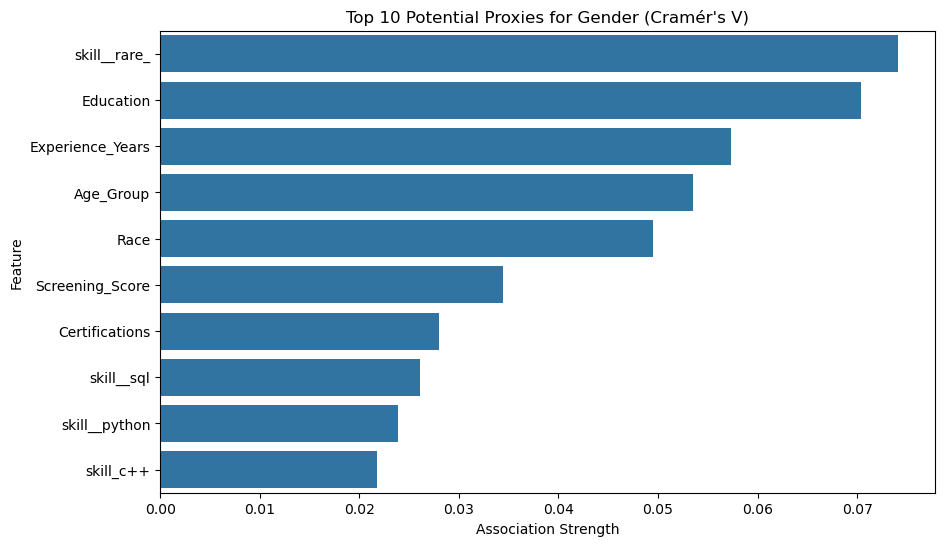

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)


Mutual Information with Gender:
 Gender              1.023469
Screening_Score     0.038130
Education           0.005120
Experience_Years    0.004217
Age_Group           0.003168
skill__rare_        0.002788
Race                0.002625
Certifications      0.000951
Selected            0.000780
skill__sql          0.000377
dtype: float64
Potential proxies for Gender (threshold=0.3): {'Gender'}
Flagged 2 potential proxy features: ['stratify_cols', 'Screening_Score']
Selected 54 fair features: ['Race', 'Education', 'Age_Group', 'Certifications', 'Experience_Years', 'skill__agile', 'skill__aws', 'skill__budgeting', 'skill__c++', 'skill__cold_calling', 'skill__communication', 'skill__conflict_resolution', 'skill__crm', 'skill__deep_learning', 'skill__git', 'skill__hr_policies', 'skill__java', 'skill__leadership', 'skill__machine_learning', 'skill__negotiation', 'skill__networking', 'skill__presentation', 'skill__python', 'skill__r', 'skill__recruitment', 'skill__scheduling', 'skill__scrum', 

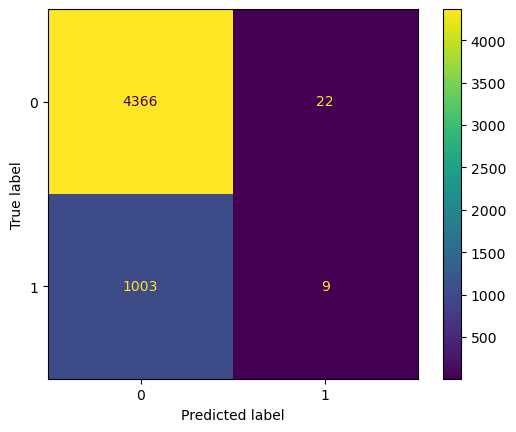

Accuracy: 0.8102
ROC AUC: 0.5346
              precision    recall  f1-score   support

         Yes       0.81      0.99      0.89      4388
          No       0.29      0.01      0.02      1012

    accuracy                           0.81      5400
   macro avg       0.55      0.50      0.46      5400
weighted avg       0.72      0.81      0.73      5400



Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Neural Network POST-MITIGATION (DP/DI/EOD):   group       SPD        DI       EOD            Fairness_Flag
2     2 -0.003197  0.778904 -0.003598  Adverse Impact (DI<0.8)
1     1 -0.002148  0.851457 -0.001304                       OK
0     0  0.000000  1.000000  0.000000                       OK


  0%|          | 0/400 [00:00<?, ?it/s]

ValueError: Post processing currently only supports a single column in sensitive_features.

In [102]:
preprocessor = PreProcessor(df=None, group_cols=['Gender'], sensitive_attrs=['Gender'])
preprocessor.load_data('../datasets/recruitment.csv')
preprocessor.fair_feature_encoding()
# preprocessor.visualization()
preprocessor.proxy_detection()
preprocessor.fair_spliting()
preprocessor.fair_feature_selection()
preprocessor.no_sampling_split()
# preprocessor.over_sample_train()
# preprocessor.under_sample_train()